# Uber Fare Prediction

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
from sklearn.ensemble import RandomForestRegressor

In [8]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load Dataset

In [9]:
df = pd.read_csv("/content/sample_data/uber.csv")

In [10]:
print(df.head())

   Unnamed: 0                            key  fare_amount  \
0    24238194    2015-05-07 19:52:06.0000003          7.5   
1    27835199    2009-07-17 20:04:56.0000002          7.7   
2    44984355   2009-08-24 21:45:00.00000061         12.9   
3    25894730    2009-06-26 08:22:21.0000001          5.3   
4    17610152  2014-08-28 17:47:00.000000188         16.0   

           pickup_datetime  pickup_longitude  pickup_latitude  \
0  2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1  2009-07-17 20:04:56 UTC        -73.994355        40.728225   
2  2009-08-24 21:45:00 UTC        -74.005043        40.740770   
3  2009-06-26 08:22:21 UTC        -73.976124        40.790844   
4  2014-08-28 17:47:00 UTC        -73.925023        40.744085   

   dropoff_longitude  dropoff_latitude  passenger_count  
0         -73.999512         40.723217                1  
1         -73.994710         40.750325                1  
2         -73.962565         40.772647                1  
3         

In [11]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB
None


In [12]:
print(df.describe())

         Unnamed: 0    fare_amount  pickup_longitude  pickup_latitude  \
count  2.000000e+05  200000.000000     200000.000000    200000.000000   
mean   2.771250e+07      11.359955        -72.527638        39.935885   
std    1.601382e+07       9.901776         11.437787         7.720539   
min    1.000000e+00     -52.000000      -1340.648410       -74.015515   
25%    1.382535e+07       6.000000        -73.992065        40.734796   
50%    2.774550e+07       8.500000        -73.981823        40.752592   
75%    4.155530e+07      12.500000        -73.967154        40.767158   
max    5.542357e+07     499.000000         57.418457      1644.421482   

       dropoff_longitude  dropoff_latitude  passenger_count  
count      199999.000000     199999.000000    200000.000000  
mean          -72.525292         39.923890         1.684535  
std            13.117408          6.794829         1.385997  
min         -3356.666300       -881.985513         0.000000  
25%           -73.991407        

# Remove unwanted columns

In [13]:
df.drop(["Unnamed: 0","key"], axis=1, inplace=True)

# Remove missing values

In [14]:
df.dropna(inplace=True)

# Convert datetime column

In [15]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

# Extract useful features

In [16]:
df["year"] = df["pickup_datetime"].dt.year
df["month"] = df["pickup_datetime"].dt.month
df["day"] = df["pickup_datetime"].dt.day
df["hour"] = df["pickup_datetime"].dt.hour

# Remove original datetime column

In [17]:
df.drop("pickup_datetime", axis=1, inplace=True)

In [18]:
print(df.head())

   fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
0          7.5        -73.999817        40.738354         -73.999512   
1          7.7        -73.994355        40.728225         -73.994710   
2         12.9        -74.005043        40.740770         -73.962565   
3          5.3        -73.976124        40.790844         -73.965316   
4         16.0        -73.925023        40.744085         -73.973082   

   dropoff_latitude  passenger_count  year  month  day  hour  
0         40.723217                1  2015      5    7    19  
1         40.750325                1  2009      7   17    20  
2         40.772647                1  2009      8   24    21  
3         40.803349                3  2009      6   26     8  
4         40.761247                5  2014      8   28    17  


#Identify Outliers

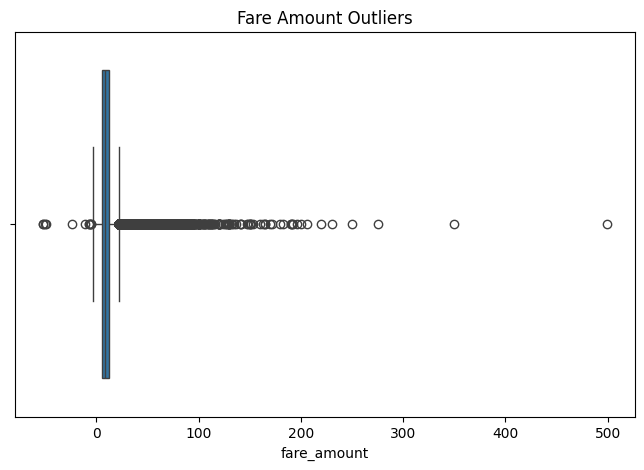

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["fare_amount"])
plt.title("Fare Amount Outliers")
plt.show()

#Remove Outliers using IQR

In [22]:
Q1 = df["fare_amount"].quantile(0.25)
Q3 = df["fare_amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["fare_amount"] >= lower) &
        (df["fare_amount"] <= upper)]

In [23]:
print(df.shape)

(182833, 10)


#Correlation

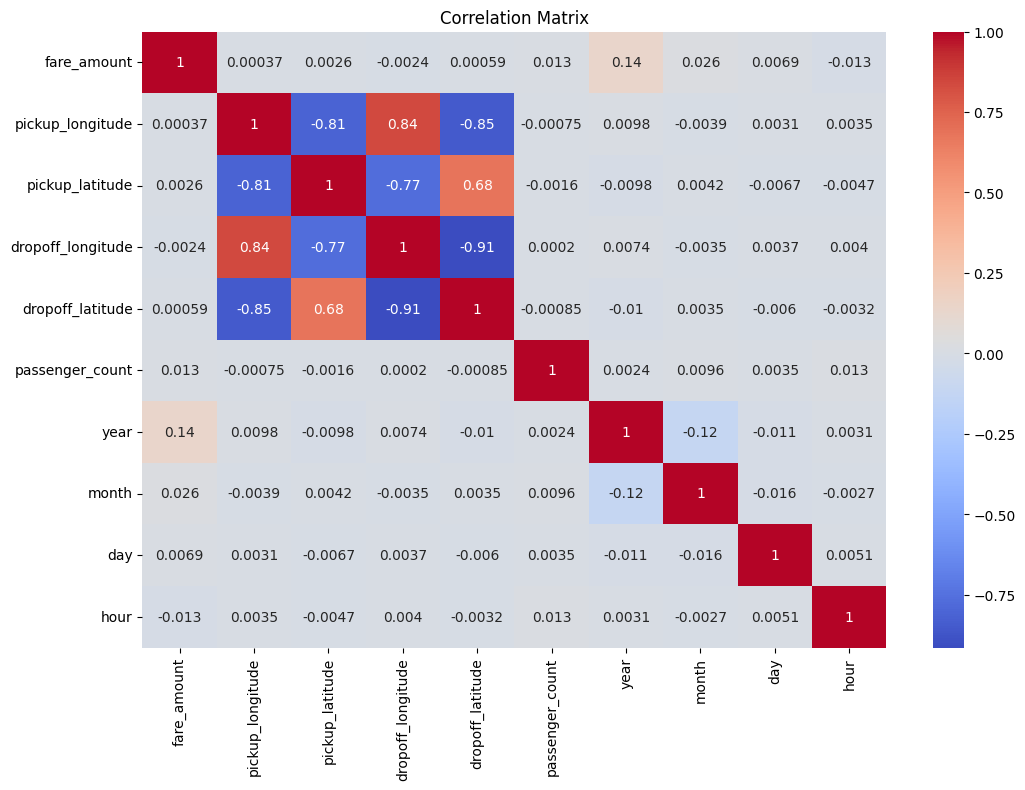

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#Prepare Features

In [25]:
X = df.drop("fare_amount", axis=1)
y = df["fare_amount"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Linear Regression

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

#Random Forest Regression

In [27]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

#Model Evaluation

Linear Regression

In [28]:
lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression")
print("R2 Score :", lr_r2)
print("RMSE :", lr_rmse)
print("MAE :", lr_mae)

Linear Regression
R2 Score : 0.02140512204502032
RMSE : 4.0922821037483095
MAE : 3.2412899460928712


Random Forest

In [29]:
rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest Regression")
print("R2 Score :", rf_r2)
print("RMSE :", rf_rmse)
print("MAE :", rf_mae)

Random Forest Regression
R2 Score : 0.7539327733052026
RMSE : 2.052064383009717
MAE : 1.400200201912471


#Comparison

In [30]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "R2 Score":[lr_r2, rf_r2],
    "RMSE":[lr_rmse, rf_rmse],
    "MAE":[lr_mae, rf_mae]
})

print(comparison)

               Model  R2 Score      RMSE      MAE
0  Linear Regression  0.021405  4.092282  3.24129
1      Random Forest  0.753933  2.052064  1.40020
